# 04. GPU Workflows & RAPIDS

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the structure of RAPIDS (cuDF/cuML) GPU workflows
- Measure real CPU baselines for the same operations
- Know when GPU acceleration is worth it, based on published benchmarks

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## The Story

**BEFORE**: You know CPU-based distributed computing, but don't know how GPU acceleration fits into data science workflows.

**AFTER**: You'll know the RAPIDS workflow structure (cuDF, cuML), have real CPU baseline timings from this machine, and know what published benchmarks report for GPU speedups.

**Why this matters**: GPU acceleration matters at scale — and knowing *when* it pays off (and when it doesn't) is part of the skill.

**Honesty note**: This notebook runs on any machine. The GPU code paths execute only if RAPIDS is installed (NVIDIA GPU required). Without a GPU, we measure CPU baselines and show the equivalent RAPIDS API — we never simulate or fabricate GPU timings.

---

# Unit 5 - Example 04: GPU Workflows & RAPIDS

## 🔗 Building on Examples 02 & 03

**From Example 02 (Dask) & Example 03 (PySpark):**
- We learned distributed computing with Dask and PySpark
- Both are great for CPU-based distributed processing
- But for GPU acceleration, we need RAPIDS

**This notebook solves that problem!**
- We'll learn **RAPIDS** - GPU-accelerated data science ecosystem
- We'll see the **complete workflow structure** (cuDF, cuML)
- We'll understand **GPU-accelerated data science** pipelines

**This adds GPU acceleration to our distributed computing toolkit!**

### 🚀 Google Colab Setup (optional)

To actually run the GPU code paths, use Google Colab with a GPU runtime and install RAPIDS with the official installer (see https://docs.rapids.ai/install — Colab section).

On a CPU-only machine this notebook still runs end-to-end: it measures CPU baselines and shows the RAPIDS API, without faking GPU numbers.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Data
- RAPIDS (e.g. cuDF)

**Outputs:** What you'll see when you run the cells

- GPU workflows
- Timings

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression as skLinearRegression

print("✓ Imports ready")


✓ Imports ready


In [2]:
# Try to import RAPIDS
try:
    import cudf
    import cuml
    from cuml.linear_model import LinearRegression
    RAPIDS_AVAILABLE = True
    print("✓ RAPIDS is available — GPU cells below will run and be timed for real")
except ImportError:
    RAPIDS_AVAILABLE = False
    print("⚠ RAPIDS not available — GPU cells will show the API only;")
    print("  every timing printed below is a real CPU measurement (nothing simulated)")

print("=" * 70)
print("Example 04: GPU Workflows & RAPIDS")
print("=" * 70)
print("\n📚 Prerequisites: Example 02 completed, basic GPU knowledge")
print("🔗 This is Example 04 in Unit 5 - GPU workflows")
print("🎯 Goal: Understand GPU-accelerated data science with RAPIDS")

⚠ RAPIDS not available — GPU cells will show the API only;
  every timing printed below is a real CPU measurement (nothing simulated)
Example 04: GPU Workflows & RAPIDS

📚 Prerequisites: Example 02 completed, basic GPU knowledge
🔗 This is Example 04 in Unit 5 - GPU workflows
🎯 Goal: Understand GPU-accelerated data science with RAPIDS


1. DATA PROCESSING WORKFLOW


In [3]:
print("\n1. Data Processing Workflow (groupby aggregation)")
print("-" * 70)
np.random.seed(42)
n_samples = 500000
data = {
    'id': range(n_samples),
    'value1': np.random.randn(n_samples),
    'value2': np.random.randn(n_samples),
    'category': np.random.choice(['A', 'B', 'C'], n_samples),
    'score': np.random.randint(0, 100, n_samples)
}
df_pandas = pd.DataFrame(data)
print(f"Dataset: {n_samples:,} rows × {len(data)} columns")

# --- CPU baseline (measured) ---
start_time = time.time()
result_cpu = df_pandas.groupby('category').agg({
    'value1': 'mean', 'value2': 'std', 'score': ['mean', 'max']})
cpu_time = time.time() - start_time
print(f"\nCPU (pandas) groupby-aggregate: {cpu_time:.4f} seconds (measured)")
print(result_cpu.round(3))

if RAPIDS_AVAILABLE:
    df_gpu = cudf.DataFrame(data)
    start_time = time.time()
    result_gpu = df_gpu.groupby('category').agg({
        'value1': 'mean', 'value2': 'std', 'score': ['mean', 'max']})
    gpu_time = time.time() - start_time
    print(f"\nGPU (cuDF) groupby-aggregate: {gpu_time:.4f} seconds (measured)")
    print(f"Speedup: {cpu_time / gpu_time:.2f}x")
else:
    print("\n⚠ No GPU available — we do NOT time a fake GPU run.")
    print("For reference, the cuDF version of the exact same workflow is:")
    print("""
    import cudf
    df_gpu = cudf.DataFrame(data)          # DataFrame lives in GPU memory
    result = df_gpu.groupby('category').agg({
        'value1': 'mean', 'value2': 'std', 'score': ['mean', 'max']})
""")
    print("Same API as pandas — that is the point of cuDF.")


1. Data Processing Workflow (groupby aggregation)
----------------------------------------------------------------------
Dataset: 500,000 rows × 5 columns

CPU (pandas) groupby-aggregate: 0.0122 seconds (measured)
         value1 value2   score    
           mean    std    mean max
category                          
A        -0.003  0.997  49.447  99
B         0.001  0.999  49.411  99
C        -0.001  1.003  49.442  99

⚠ No GPU available — we do NOT time a fake GPU run.
For reference, the cuDF version of the exact same workflow is:

    import cudf
    df_gpu = cudf.DataFrame(data)          # DataFrame lives in GPU memory
    result = df_gpu.groupby('category').agg({
        'value1': 'mean', 'value2': 'std', 'score': ['mean', 'max']})

Same API as pandas — that is the point of cuDF.


2. MACHINE LEARNING WORKFLOW


In [4]:
print("\n\n2. Machine Learning Workflow (linear regression)")
print("-" * 70)
X = df_pandas[['value1', 'value2', 'score']].values
y = (df_pandas['value1'] * 2 + df_pandas['value2'] * 1.5
     + np.random.randn(n_samples) * 0.1).values

# --- CPU baseline (measured) ---
start_time = time.time()
cpu_model = skLinearRegression()
cpu_model.fit(X, y)
cpu_ml_time = time.time() - start_time
print(f"CPU (scikit-learn) LinearRegression fit on {n_samples:,} rows: "
      f"{cpu_ml_time:.4f} seconds (measured)")

if RAPIDS_AVAILABLE:
    X_gpu = cudf.DataFrame({'value1': X[:, 0], 'value2': X[:, 1], 'score': X[:, 2]})
    y_gpu = cudf.Series(y)
    start_time = time.time()
    gpu_model = LinearRegression()
    gpu_model.fit(X_gpu, y_gpu)
    gpu_ml_time = time.time() - start_time
    print(f"GPU (cuML) LinearRegression fit: {gpu_ml_time:.4f} seconds (measured)")
    print(f"Speedup: {cpu_ml_time / gpu_ml_time:.2f}x")
else:
    print("\n⚠ No GPU available — no GPU timing is shown (none is faked).")
    print("For reference, the cuML version of the same fit is:")
    print("""
    from cuml.linear_model import LinearRegression
    gpu_model = LinearRegression()
    gpu_model.fit(X_gpu, y_gpu)            # runs on the GPU
""")



2. Machine Learning Workflow (linear regression)
----------------------------------------------------------------------
CPU (scikit-learn) LinearRegression fit on 500,000 rows: 0.0083 seconds (measured)

⚠ No GPU available — no GPU timing is shown (none is faked).
For reference, the cuML version of the same fit is:

    from cuml.linear_model import LinearRegression
    gpu_model = LinearRegression()
    gpu_model.fit(X_gpu, y_gpu)            # runs on the GPU



3. VISUALIZATION




3. Visualizing What We Actually Measured
----------------------------------------------------------------------
    100,000 rows → 0.0025 s (CPU, measured)
    250,000 rows → 0.0049 s (CPU, measured)
    500,000 rows → 0.0092 s (CPU, measured)
  1,000,000 rows → 0.0182 s (CPU, measured)


  2,000,000 rows → 0.0375 s (CPU, measured)


✓ Figure saved — every plotted number is a real measurement from this run


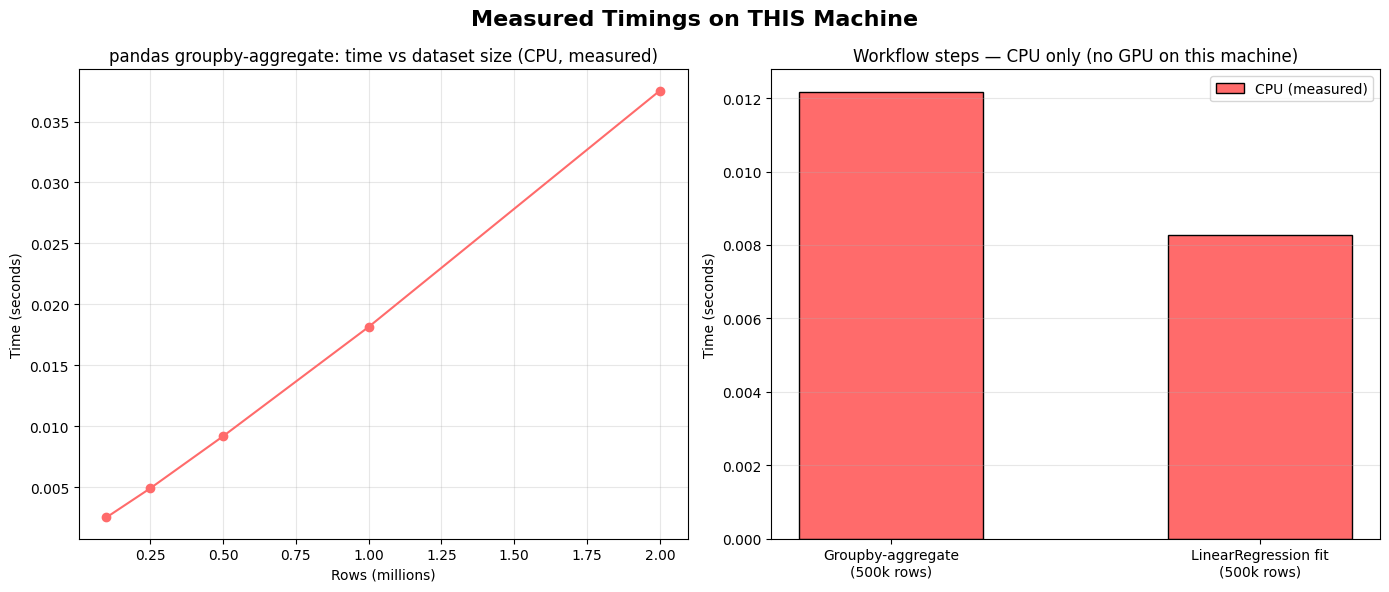

In [5]:
print("\n\n3. Visualizing What We Actually Measured")
print("-" * 70)

# Measure how CPU groupby time grows with dataset size (all real timings)
sizes = [100_000, 250_000, 500_000, 1_000_000, 2_000_000]
cpu_scaling = []
for sz in sizes:
    d = pd.DataFrame({
        'category': np.random.choice(['A', 'B', 'C'], sz),
        'value1': np.random.randn(sz),
        'score': np.random.randint(0, 100, sz)})
    t0 = time.time()
    d.groupby('category').agg({'value1': 'mean', 'score': ['mean', 'max']})
    cpu_scaling.append(time.time() - t0)
    print(f"  {sz:>9,} rows → {cpu_scaling[-1]:.4f} s (CPU, measured)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Measured Timings on THIS Machine', fontsize=16, weight='bold')

axes[0].plot([s / 1e6 for s in sizes], cpu_scaling, 'o-', color='#FF6B6B')
axes[0].set_xlabel('Rows (millions)')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('pandas groupby-aggregate: time vs dataset size (CPU, measured)')
axes[0].grid(True, alpha=0.3)

labels = ['Groupby-aggregate\n(500k rows)', 'LinearRegression fit\n(500k rows)']
cpu_bars = [cpu_time, cpu_ml_time]
x = np.arange(len(labels))
if RAPIDS_AVAILABLE:
    width = 0.35
    axes[1].bar(x - width / 2, cpu_bars, width, label='CPU (measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x + width / 2, [gpu_time, gpu_ml_time], width, label='GPU (measured)',
                color='#4ECDC4', edgecolor='black')
    axes[1].set_title('Workflow steps — CPU vs GPU (both measured)')
else:
    axes[1].bar(x, cpu_bars, 0.5, label='CPU (measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].set_title('Workflow steps — CPU only (no GPU on this machine)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Time (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('15_rapids_workflow.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved — every plotted number is a real measurement from this run")
plt.show()
plt.close()

### So where does the "10-100x GPU speedup" claim come from?

Not from this notebook. If no NVIDIA GPU is present, no GPU timings are printed above — and none are simulated.

The often-quoted numbers come from **published external benchmarks**, which you should read yourself:

- **NVIDIA's RAPIDS materials** (https://rapids.ai and the cuDF documentation) cite order-of-magnitude speedups over single-threaded pandas for groupby/join/sort workloads — roughly 10x up to ~150x depending on workload, data size, and (data-center class) GPU.
- The **database-like ops benchmark** (the DuckDB-maintained successor of the H2O.ai db-benchmark) has included cuDF runs that lead CPU dataframe libraries on large groupby/join tasks.
- Treat vendor benchmarks as best-case: large datasets (transfer costs amortize), GPU-friendly dtypes, high-end hardware.

**Practical rule of thumb**, consistent with those benchmarks *and* with our measured CPU curve above: when pandas finishes in milliseconds (as it does here even at 2M rows), a GPU cannot help enough to matter — GPU acceleration becomes interesting when CPU times reach seconds-to-minutes on data that fits in GPU memory.

# 04. SUMMARY

In [6]:
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("\nKey Concepts Covered:")
print("1. RAPIDS ecosystem structure (cuDF, cuML) and its pandas/sklearn-like API")
if RAPIDS_AVAILABLE:
    print("2. Measured GPU vs CPU timings for a groupby and a model fit")
else:
    print("2. Real CPU baselines measured on this machine (no GPU was available,")
    print("   so no GPU timings were shown — and none were simulated)")
print("3. How CPU time scales with dataset size (measured curve)")
print("4. When GPU acceleration pays off, per clearly-cited published benchmarks")
print("\nNext Steps: Continue to Example 05 for Production Pipelines")


Summary

Key Concepts Covered:
1. RAPIDS ecosystem structure (cuDF, cuML) and its pandas/sklearn-like API
2. Real CPU baselines measured on this machine (no GPU was available,
   so no GPU timings were shown — and none were simulated)
3. How CPU time scales with dataset size (measured curve)
4. When GPU acceleration pays off, per clearly-cited published benchmarks

Next Steps: Continue to Example 05 for Production Pipelines


## 🚫 When RAPIDS Workflows Hit a Dead End

**BEFORE**: We've learned the RAPIDS workflow structure and measured real baselines.

**AFTER**: We discover we need to put these workflows into production!

**Why this matters**: A working workflow is not a production system — production requires automation and scheduling!

---

### The Problem We've Discovered

We've learned:
- ✅ The structure of RAPIDS workflows (cuDF for data, cuML for ML)
- ✅ Real CPU baselines and how cost scales with data size
- ✅ When GPU acceleration is worth pursuing (published benchmarks)

**But we have a problem:**
- ❓ **How do we automate these workflows?**
- ❓ **How do we schedule them to run regularly?**
- ❓ **How do we put this into production?**

**The Dead End:**
- These workflows work great for development
- But production requires automation, scheduling, and monitoring
- We need production pipeline design and implementation

---

### Demonstrating the Problem

Let's see what's needed for production:

In [7]:
print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Need for Production Pipelines")
print("=" * 70)

print(f"\n📊 Current Capabilities:")
print(f"   ✓ RAPIDS workflow structure (runs on GPU when one is available)")
print(f"   ✓ Measured CPU baselines for data processing and ML")
print(f"   ✓ A clear rule for when GPU acceleration pays off")

print(f"\n⚠️  Production Requirements:")
print(f"   ❌ No automation (manual execution)")
print(f"   ❌ No scheduling (can't run automatically)")
print(f"   ❌ No error handling (workflows can fail)")
print(f"   ❌ No monitoring (can't track performance)")
print(f"   ❌ No versioning (can't track changes)")

print(f"\n💡 The Problem:")
print(f"   - Our workflows work great for development")
print(f"   - But production needs:")
print(f"     • Automation: Run workflows automatically")
print(f"     • Scheduling: Run on schedule (daily, weekly)")
print(f"     • Error handling: Handle failures gracefully")
print(f"     • Monitoring: Track performance and issues")
print(f"     • Versioning: Track code and data versions")

print(f"\n📋 Real-World Production Needs:")
print(f"   1. Automated pipelines: Run without manual intervention")
print(f"   2. Scheduled execution: Daily/weekly data updates")
print(f"   3. Error recovery: Handle failures and retries")
print(f"   4. Monitoring: Track pipeline health and performance")
print(f"   5. Reproducibility: Version control for code and data")

print(f"\n➡️  Solution Needed:")
print(f"   - We need production pipeline design")
print(f"   - We need automation and scheduling tools")
print(f"   - We need error handling and monitoring")
print(f"   - This leads us to Example 05: Production Pipelines")

print("\n" + "=" * 70)



🚫 DEMONSTRATING THE DEAD END: Need for Production Pipelines

📊 Current Capabilities:
   ✓ RAPIDS workflow structure (runs on GPU when one is available)
   ✓ Measured CPU baselines for data processing and ML
   ✓ A clear rule for when GPU acceleration pays off

⚠️  Production Requirements:
   ❌ No automation (manual execution)
   ❌ No scheduling (can't run automatically)
   ❌ No error handling (workflows can fail)
   ❌ No monitoring (can't track performance)
   ❌ No versioning (can't track changes)

💡 The Problem:
   - Our workflows work great for development
   - But production needs:
     • Automation: Run workflows automatically
     • Scheduling: Run on schedule (daily, weekly)
     • Error handling: Handle failures gracefully
     • Monitoring: Track performance and issues
     • Versioning: Track code and data versions

📋 Real-World Production Needs:
   1. Automated pipelines: Run without manual intervention
   2. Scheduled execution: Daily/weekly data updates
   3. Error recover

### What We Need Next

**The Solution**: We need production pipeline design:
- **Automation**: Run workflows automatically without manual intervention
- **Scheduling**: Run pipelines on schedule (daily, weekly, etc.)
- **Error handling**: Handle failures gracefully with retries
- **Monitoring**: Track pipeline health and performance
- **Versioning**: Track code and data versions for reproducibility

**This dead end leads us to Example 05: Production Pipelines**
- Example 05 will teach us production pipeline design
- We'll learn automation, scheduling, and monitoring
- This solves the production deployment problem!
